In [1]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt


In [2]:
# Input
kualitas = np.arange(0, 10.1, 0.1)
pelayanan = np.arange(0, 10.1, 0.1)
harga = np.arange(20000, 200001, 1000)

# Output
kepuasan = np.arange(0, 101, 1)


In [3]:

# Kualitas Makanan
kualitas_buruk = fuzz.trimf(kualitas, [0, 0, 4])
kualitas_sedang = fuzz.trimf(kualitas, [3, 5, 7])
kualitas_bagus = fuzz.trimf(kualitas, [6, 10, 10])

# Pelayanan
pelayanan_buruk = fuzz.trimf(pelayanan, [0, 0, 4])
pelayanan_sedang = fuzz.trimf(pelayanan, [3, 5, 7])
pelayanan_bagus = fuzz.trimf(pelayanan, [6, 10, 10])

# Harga (dalam ribuan)
harga_murah = fuzz.trimf(harga, [20000, 20000, 80000])
harga_sedang = fuzz.trimf(harga, [60000, 100000, 140000])
harga_mahal = fuzz.trimf(harga, [120000, 200000, 200000])

# Kepuasan Pelanggan
kepuasan_rendah = fuzz.trimf(kepuasan, [0, 0, 40])
kepuasan_sedang = fuzz.trimf(kepuasan, [30, 50, 70])
kepuasan_tinggi = fuzz.trimf(kepuasan, [60, 100, 100])


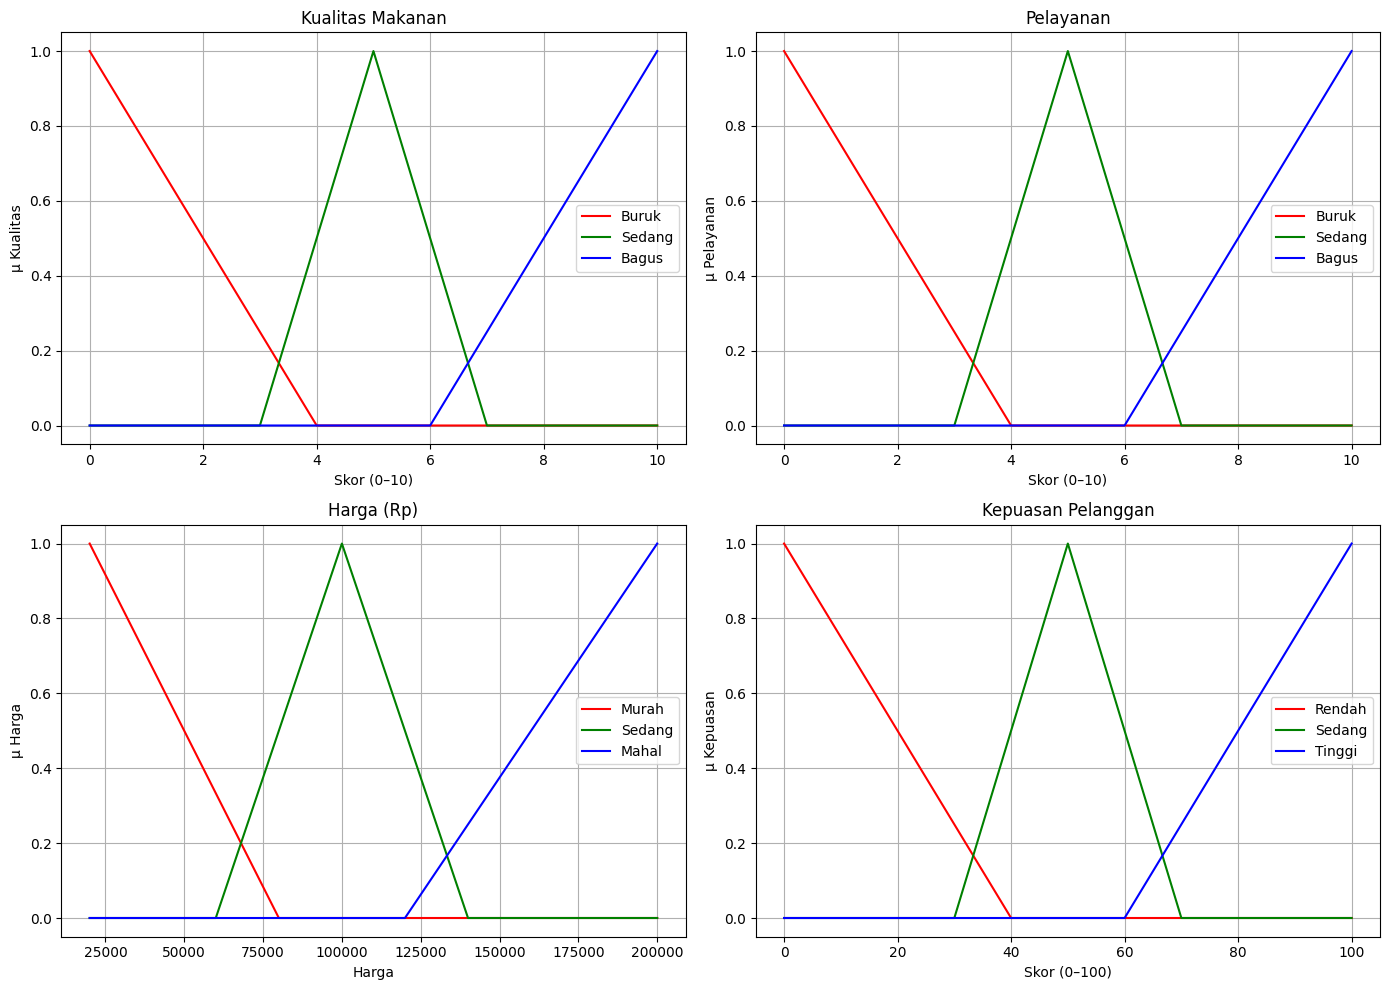

In [4]:
plt.figure(figsize=(14, 10))

# Plot Kualitas
plt.subplot(2, 2, 1)
plt.plot(kualitas, kualitas_buruk, 'r', label='Buruk')
plt.plot(kualitas, kualitas_sedang, 'g', label='Sedang')
plt.plot(kualitas, kualitas_bagus, 'b', label='Bagus')
plt.title('Kualitas Makanan')
plt.xlabel('Skor (0–10)')
plt.ylabel('μ Kualitas')
plt.legend()
plt.grid(True)

# Plot Pelayanan
plt.subplot(2, 2, 2)
plt.plot(pelayanan, pelayanan_buruk, 'r', label='Buruk')
plt.plot(pelayanan, pelayanan_sedang, 'g', label='Sedang')
plt.plot(pelayanan, pelayanan_bagus, 'b', label='Bagus')
plt.title('Pelayanan')
plt.xlabel('Skor (0–10)')
plt.ylabel('μ Pelayanan')
plt.legend()
plt.grid(True)

# Plot Harga
plt.subplot(2, 2, 3)
plt.plot(harga, harga_murah, 'r', label='Murah')
plt.plot(harga, harga_sedang, 'g', label='Sedang')
plt.plot(harga, harga_mahal, 'b', label='Mahal')
plt.title('Harga (Rp)')
plt.xlabel('Harga')
plt.ylabel('μ Harga')
plt.legend()
plt.grid(True)

# Plot Kepuasan
plt.subplot(2, 2, 4)
plt.plot(kepuasan, kepuasan_rendah, 'r', label='Rendah')
plt.plot(kepuasan, kepuasan_sedang, 'g', label='Sedang')
plt.plot(kepuasan, kepuasan_tinggi, 'b', label='Tinggi')
plt.title('Kepuasan Pelanggan')
plt.xlabel('Skor (0–100)')
plt.ylabel('μ Kepuasan')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## **📘Basis Aturan Fuzzy (Rule Base)**

> **Basis Aturan (Rule Base) – Sistem Fuzzy Mamdani**
>
> | No | Aturan Logis                                                                       |
> | -- | ---------------------------------------------------------------------------------- |
> | 1  | IF *Kualitas* Bagus AND *Pelayanan* Bagus AND *Harga* Murah → *Kepuasan* Tinggi    |
> | 2  | IF *Kualitas* Bagus AND *Pelayanan* Sedang AND *Harga* Sedang → *Kepuasan* Tinggi  |
> | 3  | IF *Kualitas* Bagus AND *Pelayanan* Bagus AND *Harga* Mahal → *Kepuasan* Sedang    |
> | 4  | IF *Kualitas* Sedang AND *Pelayanan* Sedang AND *Harga* Sedang → *Kepuasan* Sedang |
> | 5  | IF *Kualitas* Buruk AND *Pelayanan* Buruk AND *Harga* Murah → *Kepuasan* Sedang    |
> | 6  | IF *Kualitas* Buruk AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Rendah    |
> | 7  | IF *Kualitas* Sedang AND *Pelayanan* Bagus AND *Harga* Sedang → *Kepuasan* Tinggi  |
> | 8  | IF *Kualitas* Bagus AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Sedang    |
> | 9  | IF *Kualitas* Buruk AND *Pelayanan* Sedang AND *Harga* Murah → *Kepuasan* Rendah   |
> | 10 | IF *Kualitas* Sedang AND *Pelayanan* Bagus AND *Harga* Murah → *Kepuasan* Tinggi   |
> | 11 | IF *Kualitas* Sedang AND *Pelayanan* Buruk AND *Harga* Mahal → *Kepuasan* Rendah   |
> | 12 | IF *Kualitas* Bagus AND *Pelayanan* Buruk AND *Harga* Murah → *Kepuasan* Sedang    |

Aturan di atas menyeimbangkan berbagai kombinasi agar sistem bisa merespons dengan realistis:

* Aturan (1,2,7,10) → kasus pelayanan bagus & harga wajar → *Kepuasan tinggi*
* Aturan (3,4,5,8,12) → kasus sedang atau harga mahal → *Kepuasan sedang*
* Aturan (6,9,11) → kasus buruk atau harga mahal dengan pelayanan jelek → *Kepuasan rendah*



In [13]:
def basis_aturan(derajat_kualitas, derajat_pelayanan, derajat_harga, mf_output):
    """
    derajat_kualitas, derajat_pelayanan, derajat_harga: dict
        contoh: {'buruk': 0.2, 'sedang': 0.7, 'bagus': 0.9}
    mf_output: dict
        contoh: {'rendah': kepuasan_rendah, 'sedang': kepuasan_sedang, 'tinggi': kepuasan_tinggi}
    return: dict of rule outputs
    """
    rules = {}

    # 1. Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi
    r1 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['bagus']), derajat_harga['murah'])
    rules['rule1'] = np.fmin(r1, mf_output['tinggi'])

    # 2. Kualitas Bagus ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Tinggi
    r2 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['sedang']), derajat_harga['sedang'])
    rules['rule2'] = np.fmin(r2, mf_output['tinggi'])

    # 3. Kualitas Bagus ∧ Pelayanan Bagus ∧ Harga Mahal → Kepuasan Sedang
    r3 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['bagus']), derajat_harga['mahal'])
    rules['rule3'] = np.fmin(r3, mf_output['sedang'])

    # 4. Kualitas Sedang ∧ Pelayanan Sedang ∧ Harga Sedang → Kepuasan Sedang
    r4 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['sedang']), derajat_harga['sedang'])
    rules['rule4'] = np.fmin(r4, mf_output['sedang'])

    # 5. Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang
    r5 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['buruk']), derajat_harga['murah'])
    rules['rule5'] = np.fmin(r5, mf_output['sedang'])

    # 6. Kualitas Buruk ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah
    r6 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule6'] = np.fmin(r6, mf_output['rendah'])

    # 7. Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Sedang → Kepuasan Tinggi
    r7 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['bagus']), derajat_harga['sedang'])
    rules['rule7'] = np.fmin(r7, mf_output['tinggi'])

    # 8. Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Sedang
    r8 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule8'] = np.fmin(r8, mf_output['sedang'])

    # 9. Kualitas Buruk ∧ Pelayanan Sedang ∧ Harga Murah → Kepuasan Rendah
    r9 = np.fmin(np.fmin(derajat_kualitas['buruk'], derajat_pelayanan['sedang']), derajat_harga['murah'])
    rules['rule9'] = np.fmin(r9, mf_output['rendah'])

    # 10. Kualitas Sedang ∧ Pelayanan Bagus ∧ Harga Murah → Kepuasan Tinggi
    r10 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['bagus']), derajat_harga['murah'])
    rules['rule10'] = np.fmin(r10, mf_output['tinggi'])

    # 11. Kualitas Sedang ∧ Pelayanan Buruk ∧ Harga Mahal → Kepuasan Rendah
    r11 = np.fmin(np.fmin(derajat_kualitas['sedang'], derajat_pelayanan['buruk']), derajat_harga['mahal'])
    rules['rule11'] = np.fmin(r11, mf_output['rendah'])

    # 12. Kualitas Bagus ∧ Pelayanan Buruk ∧ Harga Murah → Kepuasan Sedang
    r12 = np.fmin(np.fmin(derajat_kualitas['bagus'], derajat_pelayanan['buruk']), derajat_harga['murah'])
    rules['rule12'] = np.fmin(r12, mf_output['sedang'])

    for i, (k,v) in enumerate(rules.items(), 1):
        print(f"Rule {i}: max={np.max(v):.3f}")


    return rules


In [14]:
def visualisasi_output(domain, aggregated, crisp_value, title="Hasil Fuzzy Mamdani"):
    """
    Menampilkan grafik hasil agregasi fuzzy dan titik defuzzifikasi (centroid).
    domain       : np.array domain output (contoh: kepuasan)
    aggregated   : hasil gabungan dari semua rule
    crisp_value  : nilai defuzzifikasi (centroid)
    """
    activation = fuzz.interp_membership(domain, aggregated, crisp_value)

    plt.figure(figsize=(8, 4))
    plt.fill_between(domain, 0, aggregated, facecolor='orange', alpha=0.7, label='Agregasi Output')
    plt.plot([crisp_value, crisp_value], [0, activation], 'k', linewidth=2, label='Centroid')
    plt.title(title)
    plt.xlabel('Kepuasan (0–100)')
    plt.ylabel('Derajat Keanggotaan')
    plt.legend()
    plt.grid(True)
    plt.show()


In [15]:
def visualisasi_rules(rules, domain, title_prefix="Rule"):
    """
    Menampilkan visualisasi tiap rule fuzzy (hasil clipping dari mf_output).
    rules  : dict hasil dari basis_aturan()
    domain : domain output (contoh: kepuasan)
    """
    n_rules = len(rules)
    n_cols = 3
    n_rows = int(np.ceil(n_rules / n_cols))

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axs = axs.flatten()

    for i, (key, output) in enumerate(rules.items()):
        axs[i].plot(domain, output, 'orange', alpha=0.7)
        axs[i].set_title(f"{title_prefix} {i+1}")
        axs[i].set_xlim([domain.min(), domain.max()])
        axs[i].set_ylim([0, 1])
        axs[i].grid(True)

    # Kosongkan subplot sisa kalau jumlah rule gak habis pas bagi kolom
    for j in range(i+1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()


In [16]:
def mamdani(input_kualitas, input_pelayanan, input_harga):
    # Fuzzifikasi input
    derajat_kualitas_buruk = fuzz.interp_membership(kualitas, kualitas_buruk, input_kualitas)
    derajat_kualitas_sedang = fuzz.interp_membership(kualitas, kualitas_sedang, input_kualitas)
    derajat_kualitas_bagus = fuzz.interp_membership(kualitas, kualitas_bagus, input_kualitas)

    derajat_pelayanan_buruk = fuzz.interp_membership(pelayanan, pelayanan_buruk, input_pelayanan)
    derajat_pelayanan_sedang = fuzz.interp_membership(pelayanan, pelayanan_sedang, input_pelayanan)
    derajat_pelayanan_bagus = fuzz.interp_membership(pelayanan, pelayanan_bagus, input_pelayanan)

    derajat_harga_murah = fuzz.interp_membership(harga, harga_murah, input_harga)
    derajat_harga_sedang = fuzz.interp_membership(harga, harga_sedang, input_harga)
    derajat_harga_mahal = fuzz.interp_membership(harga, harga_mahal, input_harga)

    derajat_kualitas = {
    'buruk': derajat_kualitas_buruk,
    'sedang': derajat_kualitas_sedang,
    'bagus': derajat_kualitas_bagus
    }
    derajat_pelayanan = {
        'buruk': derajat_pelayanan_buruk,
        'sedang': derajat_pelayanan_sedang,
        'bagus': derajat_pelayanan_bagus
    }
    derajat_harga = {
        'murah': derajat_harga_murah,
        'sedang': derajat_harga_sedang,
        'mahal': derajat_harga_mahal
    }

    mf_output = {
    'rendah': kepuasan_rendah,
    'sedang': kepuasan_sedang,
    'tinggi': kepuasan_tinggi
    }


    rules = basis_aturan(derajat_kualitas, derajat_pelayanan, derajat_harga, mf_output)
    aggregated_mamdani = np.fmax.reduce(list(rules.values()))
    output_crisp = fuzz.defuzz(kepuasan, aggregated_mamdani, 'centroid')

    dom_rendah = fuzz.interp_membership(kepuasan, kepuasan_rendah, output_crisp)
    dom_sedang = fuzz.interp_membership(kepuasan, kepuasan_sedang, output_crisp)
    dom_tinggi = fuzz.interp_membership(kepuasan, kepuasan_tinggi, output_crisp)

    derajat_label = {
    'rendah': dom_rendah,
    'sedang': dom_sedang,
    'tinggi': dom_tinggi
    }
    
    label_dominan = max(derajat_label, key=derajat_label.get)

    return {
        'crisp': output_crisp,
        'aggregated': aggregated_mamdani,
        'rules': rules,
        'label': label_dominan
    }


    

    





Rule 1: max=0.250
Rule 2: max=0.000
Rule 3: max=0.000
Rule 4: max=0.000
Rule 5: max=0.000
Rule 6: max=0.000
Rule 7: max=0.000
Rule 8: max=0.000
Rule 9: max=0.000
Rule 10: max=0.000
Rule 11: max=0.000
Rule 12: max=0.000


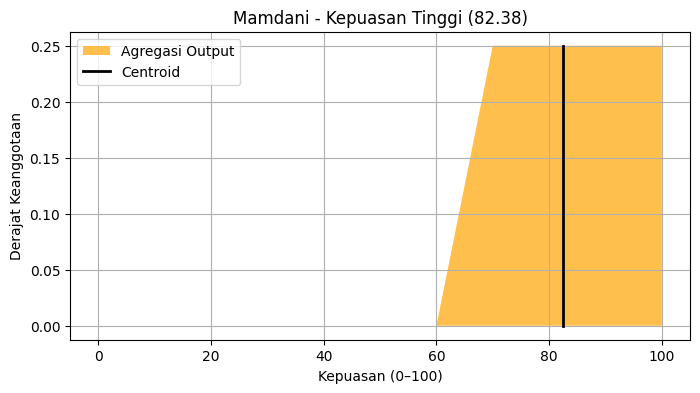

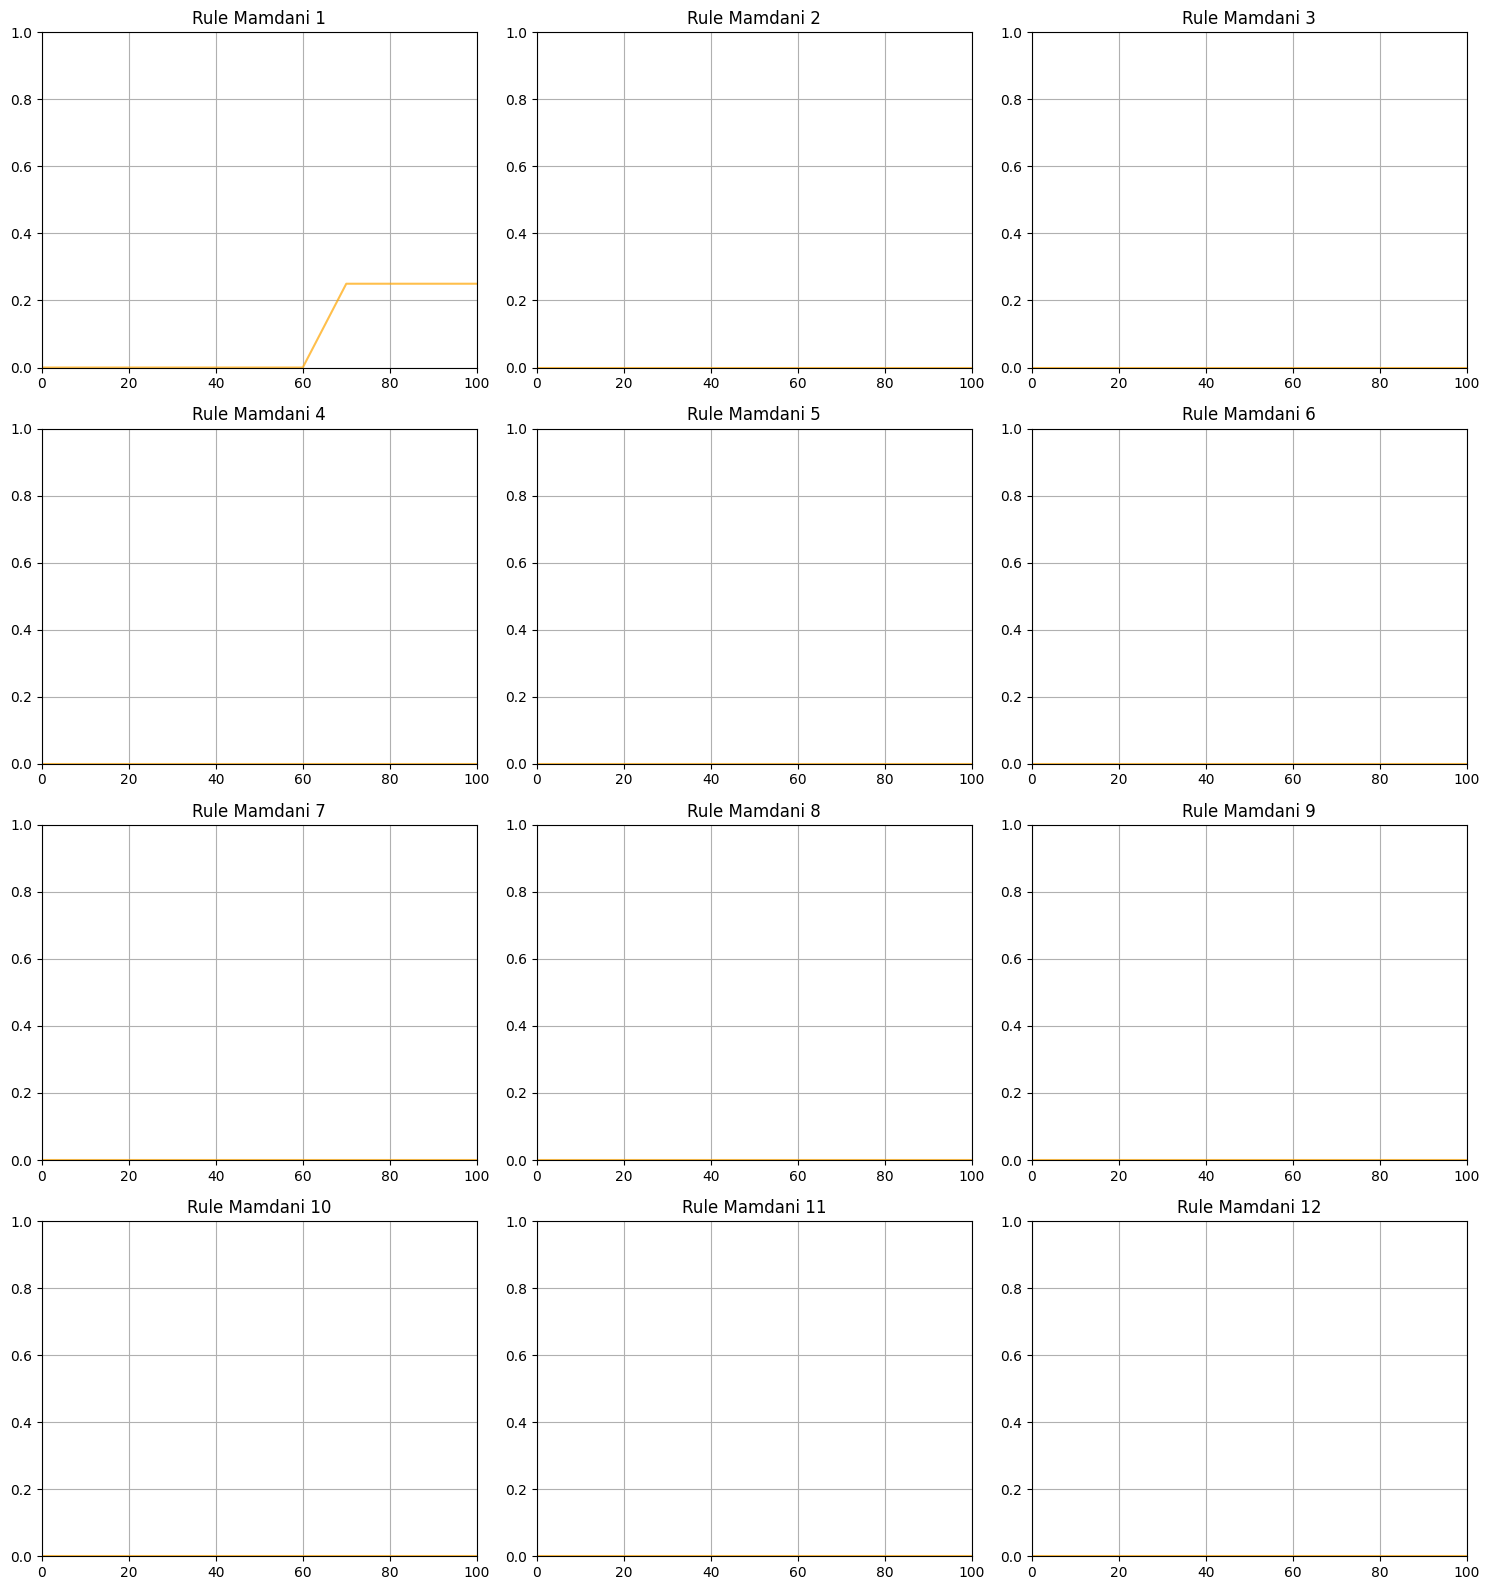

In [17]:
hasil = mamdani(7, 8, 50000)
visualisasi_output(kepuasan, hasil['aggregated'], hasil['crisp'],title=f"Mamdani - Kepuasan {hasil['label'].capitalize()} ({hasil['crisp']:.2f})")

visualisasi_rules(hasil['rules'], kepuasan, title_prefix="Rule Mamdani")
